Erosion

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
img=cv2.imread(r'E:\BG\fingerprint.tif',0)
threshold=128
binary_img=(img>threshold).astype(np.uint8)*255


In [10]:
rows, cols=binary_img.shape
kernel_size=3
pad=kernel_size//2
eroded_img=np.zeros_like(binary_img)
padded_img=np.pad(binary_img, pad, mode='constant', constant_values=255)


In [11]:
for i in range(rows):
    for j in range(cols):
        neighborhood=padded_img[i:i+kernel_size,j:j+kernel_size]
        eroded_img[i,j]=np.min(neighborhood)

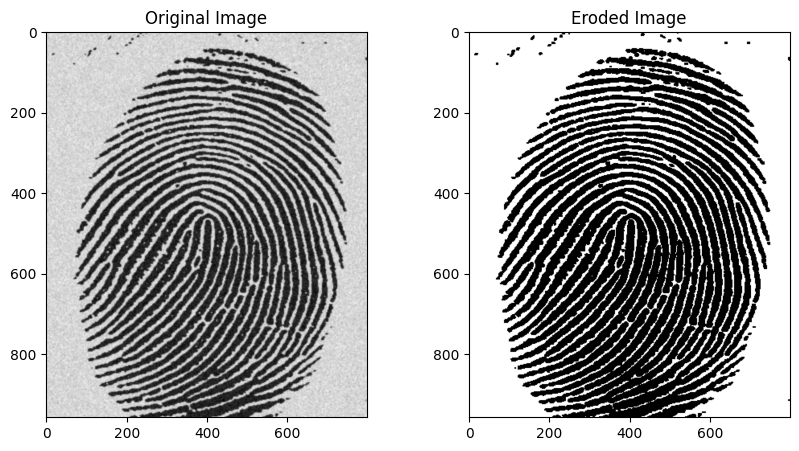

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.title('Eroded Image')
plt.imshow(eroded_img,cmap='gray')
plt.show()


Dilation

In [13]:
rows, cols=binary_img.shape
kernel_size=3
pad=kernel_size//2
dilated_img=np.zeros_like(binary_img)
padded_img=np.pad(binary_img, pad, mode='constant', constant_values=255)


In [14]:
for i in range(rows):
    for j in range(cols):
        neighborhood=padded_img[i:i+kernel_size,j:j+kernel_size]
        dilated_img[i,j]=np.max(neighborhood)

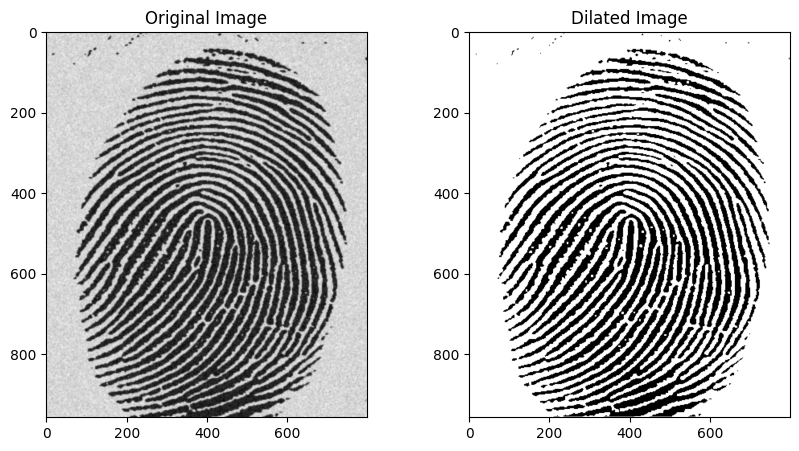

In [15]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.title('Dilated Image')
plt.imshow(dilated_img,cmap='gray')
plt.show()


THINNING

In [16]:
def match_pattern(binary_img,i,j,pattern):
    for x in range(-1,2):
        for y in range(-1,2):
            if pattern[x+1][y+1]==-1:
                continue
            if binary_img[i+x][j+y]!=pattern[x+1][y+1]:
                return False
    return True

In [17]:
changed=True
while changed:
    changed=False
    thin=[]
    for i in range(1,rows-1):
        for j in range(1,cols-1):
            if binary_img[i][j]==255:
                pattern=np.array([[0,0,0],[-1,255,-1],[255,255,255]])
                if match_pattern(binary_img,i,j,pattern):
                    thin.append((i,j))
    for i, j in thin:
        binary_img[i][j]=0
        changed=True

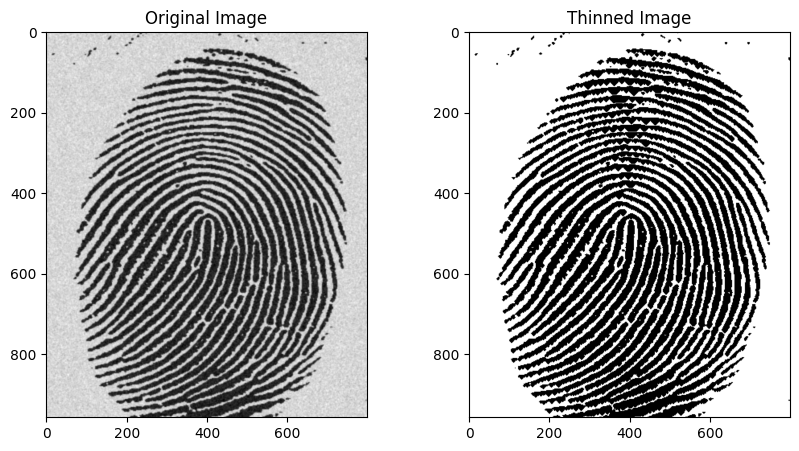

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.title('Thinned Image')
plt.imshow(binary_img,cmap='gray')
plt.show()


Thickening

In [19]:
changed = True
patterns = [
    [[0,0,0],[-1,255,-1],[255,255,255]],
    [[255,-1,0],[255,255,0],[255,-1,0]],
    [[255,255,255],[-1,255,-1],[0,0,0]],
    [[0,-1,255],[0,255,255],[0,-1,255]]
]
while changed:
    changed = False
    thick = []
    for i in range(1, rows-1):
        for j in range(1, cols-1):
           if binary_img[i][j] == 0:
                for p in patterns:
                    if match_pattern(binary_img, i, j, p):
                        thick.append((i, j))
                        break

    for i, j in thick:
        binary_img[i][j] = 255
        changed = True

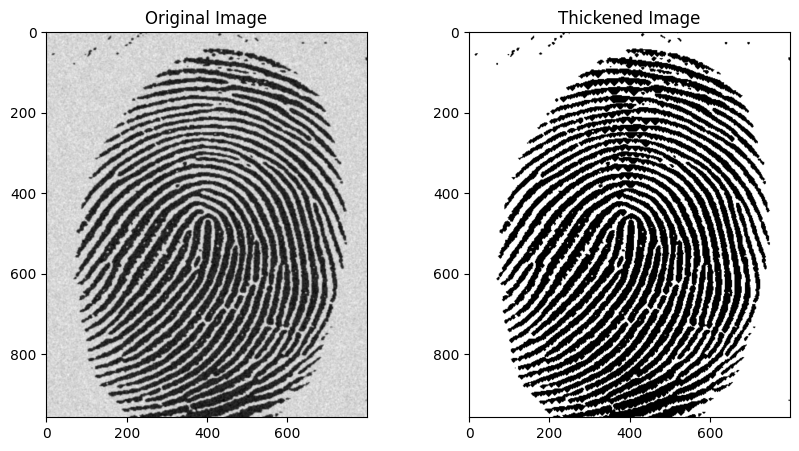

In [20]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.title('Thickened Image')
plt.imshow(binary_img,cmap='gray')
plt.show()


Opening

In [21]:
rows, cols=binary_img.shape
kernel_size=3
pad=kernel_size//2
eroded_img=np.zeros_like(binary_img)
padded_img=np.pad(binary_img, pad, mode='constant', constant_values=255)


In [22]:
for i in range(rows):
    for j in range(cols):
        neighborhood=padded_img[i:i+kernel_size,j:j+kernel_size]
        eroded_img[i,j]=np.min(neighborhood)

In [23]:
rows, cols=eroded_img.shape
kernel_size=3
pad=kernel_size//2
dilated_img=np.zeros_like(eroded_img)
padded_img=np.pad(eroded_img, pad, mode='constant', constant_values=255)


In [24]:
for i in range(rows):
    for j in range(cols):
        neighborhood=padded_img[i:i+kernel_size,j:j+kernel_size]
        dilated_img[i,j]=np.max(neighborhood)

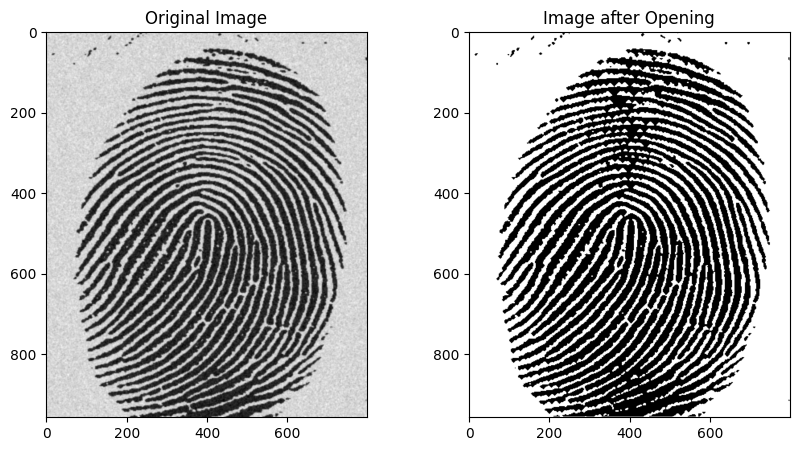

In [25]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.title('Image after Opening')
plt.imshow(dilated_img,cmap='gray')
plt.show()


Closing

In [26]:
rows, cols=binary_img.shape
kernel_size=3
pad=kernel_size//2
dilated_img=np.zeros_like(binary_img)
padded_img=np.pad(binary_img, pad, mode='constant', constant_values=255)


In [27]:
for i in range(rows):
    for j in range(cols):
        neighborhood=padded_img[i:i+kernel_size,j:j+kernel_size]
        dilated_img[i,j]=np.max(neighborhood)

In [28]:
rows, cols=dilated_img.shape
kernel_size=3
pad=kernel_size//2
eroded_img=np.zeros_like(dilated_img)
padded_img=np.pad(dilated_img, pad, mode='constant', constant_values=255)


In [29]:
for i in range(rows):
    for j in range(cols):
        neighborhood=padded_img[i:i+kernel_size,j:j+kernel_size]
        eroded_img[i,j]=np.min(neighborhood)

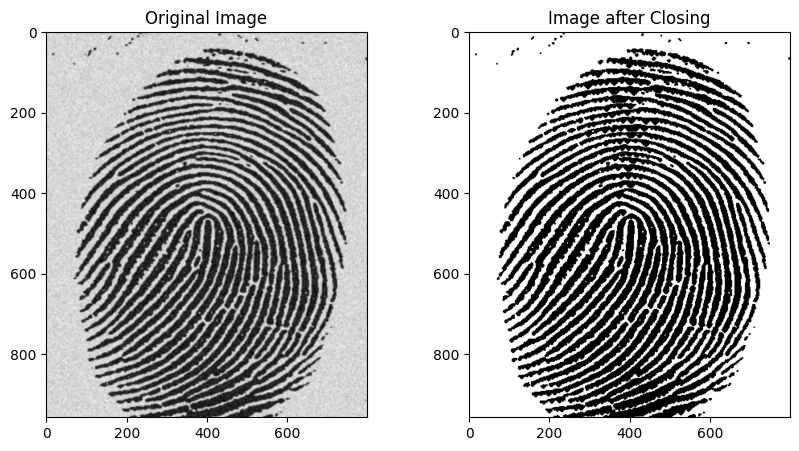

In [30]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.title('Image after Closing')
plt.imshow(eroded_img,cmap='gray')
plt.show()
